# Exercise
At the same level as this notebook on github, there is an Exercise folder that contains __carprices.csv__. This file has car **sell prices** for 3 different models. First **plot data points on a scatter plot chart** to see **_if linear regression model can be applied. If yes, then build a model that can answer following questions,_**

#### 1) Predict price of a mercedez benz that is 4 yr old with mileage 45000
#### 2) Predict price of a BMW X5 that is 7 yr old with mileage 86000
#### 3) Tell me the score (accuracy) of your model. (Hint: use LinearRegression().score())

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
#from sklearn import linear_model

In [2]:
df = pd.read_csv('carprices.csv')
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


Text(0.5, 1.0, 'Age(yrs) vs Sell Price($)')

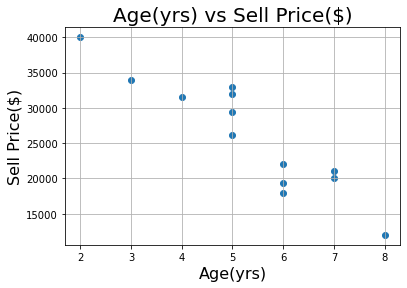

In [3]:
%matplotlib inline
plt.scatter(df['Age(yrs)'],df['Sell Price($)'])
plt.xlabel('Age(yrs)',fontsize=16)
plt.ylabel('Sell Price($)',fontsize=16)
plt.grid()
plt.title('Age(yrs) vs Sell Price($)',fontsize=20)

Text(0.5, 1.0, 'Mileage vs Sell Price($)')

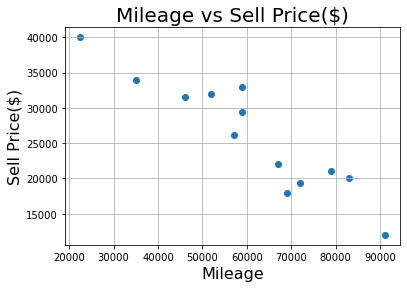

In [4]:
%matplotlib inline
plt.scatter(df['Mileage'],df['Sell Price($)'])
plt.xlabel('Mileage',fontsize=16)
plt.ylabel('Sell Price($)',fontsize=16)
plt.grid()
plt.title('Mileage vs Sell Price($)',fontsize=20)

#### Get dummies of the dataset with the help of <font color='blue'>'pandas'</font> 

In [5]:
dummies = pd.get_dummies(df['Car Model'])
dummies

,Audi A5,BMW X5,Mercedez Benz C class
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
5,1,0,0
6,1,0,0
7,1,0,0
8,1,0,0
9,0,0,1


#### Merge both the dataframes <font color='brown'>'df & 'dummies'</font> with the help of <font color='blue'>'pandas'</font> 

In [6]:
merged = pd.concat([df,dummies],axis='columns')
merged

,Car Model,Mileage,Sell Price($),Age(yrs),Audi A5,BMW X5,Mercedez Benz C class
0,BMW X5,69000,18000,6,0,1,0
1,BMW X5,35000,34000,3,0,1,0
2,BMW X5,57000,26100,5,0,1,0
3,BMW X5,22500,40000,2,0,1,0
4,BMW X5,46000,31500,4,0,1,0
5,Audi A5,59000,29400,5,1,0,0
6,Audi A5,52000,32000,5,1,0,0
7,Audi A5,72000,19300,6,1,0,0
8,Audi A5,91000,12000,8,1,0,0
9,Mercedez Benz C class,67000,22000,6,0,0,1


#### Drop the <font color='red'>'Car Model'</font>, since alread covered as categorical variables

In [7]:
merged = merged.drop(['Car Model'],axis='columns')
merged

,Mileage,Sell Price($),Age(yrs),Audi A5,BMW X5,Mercedez Benz C class
0,69000,18000,6,0,1,0
1,35000,34000,3,0,1,0
2,57000,26100,5,0,1,0
3,22500,40000,2,0,1,0
4,46000,31500,4,0,1,0
5,59000,29400,5,1,0,0
6,52000,32000,5,1,0,0
7,72000,19300,6,1,0,0
8,91000,12000,8,1,0,0
9,67000,22000,6,0,0,1


#### Drop the <font color='orange'>'Mercedez Benz C class'</font>, since alread covered as explain below

#### Dummy Variable Trap
When you can derive one variable from other variables, they are known to be __multi-colinear__. Here if you know values of __Audi A5 and BMW X5__ then you can easily infer the value of __Mercedez Benz C class, i.e. Audi A5 = 0 and BMW X5 = 0.__ Therefore, these state variables are called to be __multi-colinear.__ In this situation __linear regression__ won't work as expected. Hence you need to drop one column.

__NOTE: sklearn__ library takes care of __dummy variable trap__, hence even if you don't drop one of the car columns it is going to work, however we should make a habit of taking care of __dummy variable trap__ ourselves just in case library that you are using is not handling this for you

In [8]:
final = merged.drop(['Mercedez Benz C class'],axis='columns')
final

,Mileage,Sell Price($),Age(yrs),Audi A5,BMW X5
0,69000,18000,6,0,1
1,35000,34000,3,0,1
2,57000,26100,5,0,1
3,22500,40000,2,0,1
4,46000,31500,4,0,1
5,59000,29400,5,1,0
6,52000,32000,5,1,0
7,72000,19300,6,1,0
8,91000,12000,8,1,0
9,67000,22000,6,0,0


#### Prepare linear equation 
__<font color='grey'>y = m*x + b</font>__

In [9]:
X = final.drop(['Sell Price($)'],axis='columns')
X

,Mileage,Age(yrs),Audi A5,BMW X5
0,69000,6,0,1
1,35000,3,0,1
2,57000,5,0,1
3,22500,2,0,1
4,46000,4,0,1
5,59000,5,1,0
6,52000,5,1,0
7,72000,6,1,0
8,91000,8,1,0
9,67000,6,0,0


In [10]:
y = final['Sell Price($)']
y

0     18000
1     34000
2     26100
3     40000
4     31500
5     29400
6     32000
7     19300
8     12000
9     22000
10    20000
11    21000
12    33000
Name: Sell Price($), dtype: int64

In [11]:
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [12]:
model.predict(X)

array([18705.2723644 , 35286.78445645, 24479.19112468, 41245.76426391,
       29882.98779056, 28023.6135243 , 30614.46818502, 21879.57266964,
       12182.34562104, 26183.72387884, 18929.31674102, 20409.80511857,
       30477.15426156])

In [13]:
model.score(X,y)

0.9417050937281083

#### Price of mercedez benz that is 4 yr old with mileage 45000 

In [14]:
model.predict([[45000,4,0,0]])

array([36991.31721061])

#### Price of BMW X5 that is 7 yr old with mileage 86000

In [15]:
model.predict([[86000,7,0,1]])

array([11080.74313219])

In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() # Encode target labels with value between 0 and n_classes-1.

In [17]:
ohele = df
ohele

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


In [18]:
ohele['Car Model'] = le.fit_transform(ohele['Car Model']) # Fit label encoder and return encoded labels.
ohele

,Car Model,Mileage,Sell Price($),Age(yrs)
0,1,69000,18000,6
1,1,35000,34000,3
2,1,57000,26100,5
3,1,22500,40000,2
4,1,46000,31500,4
5,0,59000,29400,5
6,0,52000,32000,5
7,0,72000,19300,6
8,0,91000,12000,8
9,2,67000,22000,6


#### Create <font color='blue'>linear regression model</font> with the help of <font color='blue'>sklearn label encoder</font> 

In [19]:
X = ohele[['Car Model','Mileage','Age(yrs)']].values # 'values' to get the output in array, 
# Only the values in the DataFrame will be returned, the axes labels will be removed.
X

array([[    1, 69000,     6],
       [    1, 35000,     3],
       [    1, 57000,     5],
       [    1, 22500,     2],
       [    1, 46000,     4],
       [    0, 59000,     5],
       [    0, 52000,     5],
       [    0, 72000,     6],
       [    0, 91000,     8],
       [    2, 67000,     6],
       [    2, 83000,     7],
       [    2, 79000,     7],
       [    2, 59000,     5]], dtype=int64)

In [20]:
y = ohele['Sell Price($)'].values # 'values' to get the output in array
y

array([18000, 34000, 26100, 40000, 31500, 29400, 32000, 19300, 12000,
       22000, 20000, 21000, 33000], dtype=int64)

#### Now use one hot encoder to create dummy variables for each of the car model

In [21]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer([('Car Model',OneHotEncoder(),[0])],remainder='passthrough')

# transformers : list of tuples
#     List of (name, transformer, columns) tuples specifying the
#     transformer objects to be applied to subsets of the data.

# remainder : {'drop', 'passthrough'} or estimator, default='drop'
#     By default, only the specified columns in `transformers` are
#     transformed and combined in the output, and the non-specified
#     columns are dropped. (default of ``'drop'``).
#     By specifying ``remainder='passthrough'``, all remaining columns that
#     were not specified in `transformers` will be automatically passed
#     through. 

In [22]:
X = ct.fit_transform(X)
X

# Fit all transformers, transform the data and concatenate results.

# Parameters
# ----------
# X : {array-like, dataframe} of shape (n_samples, n_features)
#     Input data, of which specified subsets are used to fit the
#     transformers.

# y : array-like of shape (n_samples,), default=None
#     Targets for supervised learning.

array([[0.00e+00, 1.00e+00, 0.00e+00, 6.90e+04, 6.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 3.50e+04, 3.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 5.70e+04, 5.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 2.25e+04, 2.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, 4.60e+04, 4.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, 5.90e+04, 5.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, 5.20e+04, 5.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, 7.20e+04, 6.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, 9.10e+04, 8.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 6.70e+04, 6.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 8.30e+04, 7.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 7.90e+04, 7.00e+00],
       [0.00e+00, 0.00e+00, 1.00e+00, 5.90e+04, 5.00e+00]])

In [23]:
# drop a column to avoid dummy variable trap
X = X[:,1:] # all rows included but in column, inclusion begins from the 1st and then include all columns
# Slicing [0th row : till nth row, 0th column : till nth column]
X

array([[1.00e+00, 0.00e+00, 6.90e+04, 6.00e+00],
       [1.00e+00, 0.00e+00, 3.50e+04, 3.00e+00],
       [1.00e+00, 0.00e+00, 5.70e+04, 5.00e+00],
       [1.00e+00, 0.00e+00, 2.25e+04, 2.00e+00],
       [1.00e+00, 0.00e+00, 4.60e+04, 4.00e+00],
       [0.00e+00, 0.00e+00, 5.90e+04, 5.00e+00],
       [0.00e+00, 0.00e+00, 5.20e+04, 5.00e+00],
       [0.00e+00, 0.00e+00, 7.20e+04, 6.00e+00],
       [0.00e+00, 0.00e+00, 9.10e+04, 8.00e+00],
       [0.00e+00, 1.00e+00, 6.70e+04, 6.00e+00],
       [0.00e+00, 1.00e+00, 8.30e+04, 7.00e+00],
       [0.00e+00, 1.00e+00, 7.90e+04, 7.00e+00],
       [0.00e+00, 1.00e+00, 5.90e+04, 5.00e+00]])

In [24]:
model.fit(X,y)

LinearRegression()

In [25]:
model.score(X,y)

0.9417050937281083

#### Price of mercedez benz that is 4 yr old with mileage 45000
__<font color='red'>[ Audi A5 | BMW X5 | Mercedez Benz C class ]</font> <font color='blue'>[ Mileage ]</font> <font color='orange'>[ Age(yrs) ]</font>__

Here, __Mercedez Benz C__ class, has to ignore

In [26]:
model.predict([[0,0,45000,4]])

array([34537.77647335])

#### Predict price of a BMW X5 that is 7 yr old with mileage 86000 

In [27]:
model.predict([[0,1,86000,7]])

array([17818.95045785])